# **Project Name** - Ford Go Bike Project



##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary -**

## Project Summary: Ford GoBike 2018 Trip Data Analysis

**Overview**

This project analyzed twelve months of Ford GoBike trip data for 2018, combining individual monthly CSV files into a single dataset for comprehensive data wrangling, exploratory analysis, and visualization. The goal was to clean the raw trip records, uncover usage patterns, and translate those patterns into insights that could support business decision-making.

**Data Wrangling**

The wrangling phase addressed several data quality issues. Date columns (`start_time`, `end_time`) were converted from string to proper datetime format, enabling time-based analysis by hour, day, month, and season. Categorical columns (`user_type`, `member_gender`, `bike_share_for_all_trip`) were converted to category dtype for memory efficiency and cleaner grouping.

Missing values were handled thoughtfully rather than uniformly. Rows missing both station ID and station name were dropped, since these fields are essential identifiers. `member_gender` nulls were filled with an "Unknown" label to preserve row count without fabricating data. `member_birth_year`, the field with the most significant missingness, was imputed using group-wise medians by `user_type` rather than a single global median — justified by the finding that Customers had a substantially higher missing rate (~28%) than Subscribers (~2%), suggesting the missingness was not random across groups. Outlier birth years (before 1930, implying riders over 88) affected only 1,413 rows (~0.08% of data) and were removed as likely data entry errors.

**Key Findings**

*Trip Duration:* Duration is heavily right-skewed — most trips last under 15 minutes, but a long tail of extreme-duration trips pulls the average upward. These outliers likely represent lost, stolen, or improperly docked bikes rather than genuine rides, representing an operational cost rather than legitimate usage.

*User Segmentation:* Subscribers dominate total trip volume, while Customers make up a smaller share but ride for noticeably longer average durations, consistent with leisure use versus commute use. Subscribers also show tight, consistent trip patterns concentrated around weekday commute hours (roughly 8 AM and 5 PM), while Customer activity is more spread out and skews toward weekends.

*Demographics:* Age is concentrated in a mid-range adult bracket, with fewer very young or older riders. Male riders account for the largest share of trips across both user types, with Female and Other/Unknown riders comprising a smaller, underrepresented segment.

*Time Patterns:* The hour-by-day heatmap confirms sharp weekday commute peaks and comparatively flat, lower-intensity weekend usage — reinforcing that the platform's core use case is commuting rather than leisure.

*Stations:* Trip activity is concentrated among a small number of high-traffic stations, with substantial overlap between top start and end stations, indicating central hub locations rather than one-way flows across the system.

**Business Implications**

The findings point toward several actionable opportunities: prioritizing bike availability and rebalancing at peak hours and high-traffic stations; targeting casual Customers — who show longer leisure-style trips and higher missing profile data — for Subscriber conversion campaigns; and expanding outreach to underrepresented demographic segments (certain genders and age groups) to broaden the user base.

At the same time, several risks emerged: heavy reliance on a small number of stations creates vulnerability to localized disruptions; weekday-commute dependence means the business is exposed if remote work reduces commuting; and outlier-duration trips suggest ongoing fleet losses that warrant operational monitoring.

**Conclusion**

Overall, the 2018 Ford GoBike data reflects a platform primarily driven by weekday commuter usage among Subscribers, with a smaller but distinct leisure-oriented Customer segment. The wrangling and analysis process not only prepared the dataset for reliable exploration but surfaced concrete, evidence-based insights that connect rider behavior to real business decisions around fleet planning, marketing, and growth strategy.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Ford GoBike, a bike-share program operating in the San Francisco Bay Area, generates large volumes of trip-level data each month, capturing details such as trip duration, start and end stations, timestamps, and rider demographics (age, gender, user type). While this data holds valuable insight into how the service is used, it is scattered across twelve separate monthly files and contains data quality issues — inconsistent formatting, missing demographic values, and implausible outliers — that make it unsuitable for direct analysis.

The objective of this project is to consolidate the twelve monthly datasets into a single, clean, analysis-ready dataset, and to perform exploratory data analysis to uncover patterns in rider behavior. Specifically, the project aims to answer:

- How does trip duration vary across time (hour, day, month) and across rider segments (Subscriber vs. Customer)?
- What demographic and usage patterns exist among riders (age, gender, program participation)?
- Which stations experience the highest demand, and how does that demand fluctuate over time?
- What insights from this data can inform business decisions — such as fleet rebalancing, marketing strategy, and rider retention — and where do risks to growth appear in the data?

By addressing data quality issues through careful wrangling and then analyzing the cleaned dataset through univariate, bivariate, and multivariate visualizations, this project seeks to translate raw trip records into actionable insights that support Ford GoBike's operational and business planning.**

#### **Define Your Business Objective?**

#### Business Objective

The primary business objective of this analysis is to help Ford GoBike make data-driven decisions that improve operational efficiency, support revenue growth, and enhance the overall rider experience. Specifically, the analysis aims to:

- **Optimize fleet operations:** Identify peak usage hours, high-demand stations, and seasonal trends to guide bike availability, rebalancing schedules, and maintenance planning.

- **Drive Subscriber growth:** Understand behavioral differences between Subscribers and Customers to design targeted campaigns that convert casual, one-time riders into recurring Subscribers — supporting more predictable, sustainable revenue.

- **Improve rider retention and satisfaction:** Use demographic and usage pattern insights (age, gender, trip duration, program participation) to identify underserved rider segments and tailor marketing or service improvements to broaden and retain the user base.

- **Reduce operational costs:** Flag anomalies such as unusually long trip durations, which may indicate lost, stolen, or improperly returned bikes, enabling proactive fleet monitoring and loss reduction.

Ultimately, the goal is to turn raw trip-level data into actionable insights that inform strategic decisions across operations, marketing, and growth planning — helping Ford GoBike run a more efficient, profitable, and rider-friendly bike-share service.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Dataset
df1 = pd.read_csv('/content/drive/MyDrive/Ford_Go_ride/fordgobike_012018.csv')
df2 = pd.read_csv('/content/drive/MyDrive/Ford_Go_ride/fordgobike_022018.csv')
df3 = pd.read_csv('/content/drive/MyDrive/Ford_Go_ride/fordgobike_032018.csv')
df4 = pd.read_csv('/content/drive/MyDrive/Ford_Go_ride/fordgobike_042018.csv')
df5 = pd.read_csv('/content/drive/MyDrive/Ford_Go_ride/fordgobike_052018.csv')
df6 = pd.read_csv('/content/drive/MyDrive/Ford_Go_ride/fordgobike_062018.csv')
df7 = pd.read_csv('/content/drive/MyDrive/Ford_Go_ride/fordgobike_072018.csv')
df8 = pd.read_csv('/content/drive/MyDrive/Ford_Go_ride/fordgobike_082018.csv')
df9 = pd.read_csv('/content/drive/MyDrive/Ford_Go_ride/fordgobike_092018.csv')
df10 = pd.read_csv('/content/drive/MyDrive/Ford_Go_ride/fordgobike_102018.csv')
df11 = pd.read_csv('/content/drive/MyDrive/Ford_Go_ride/fordgobike_112018.csv')
df12 = pd.read_csv('/content/drive/MyDrive/Ford_Go_ride/fordgobike_122018.csv')


### Dataset First View

##### Merging all 12 datasets

In [4]:
import pandas as pd

merged_df = pd.concat(
    [df1, df2, df3, df4, df5, df6,
     df7, df8, df9, df10, df11, df12],
    ignore_index=True
)

In [5]:
# Dataset First Look
merged_df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,31-01-2018 22:52,01-02-2018 19:47,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,31-01-2018 16:13,01-02-2018 15:57,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,31-01-2018 14:23,01-02-2018 10:16,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,31-01-2018 14:53,01-02-2018 07:51,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,31-01-2018 19:52,01-02-2018 06:58,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No


### Dataset Rows & Columns count

In [6]:
merged_df.shape

(1863721, 16)

### Dataset Information

In [7]:
# Dataset Info
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   duration_sec             int64  
 1   start_time               object 
 2   end_time                 object 
 3   start_station_id         float64
 4   start_station_name       object 
 5   start_station_latitude   float64
 6   start_station_longitude  float64
 7   end_station_id           float64
 8   end_station_name         object 
 9   end_station_latitude     float64
 10  end_station_longitude    float64
 11  bike_id                  int64  
 12  user_type                object 
 13  member_birth_year        float64
 14  member_gender            object 
 15  bike_share_for_all_trip  object 
dtypes: float64(7), int64(2), object(7)
memory usage: 227.5+ MB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
merged_df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
merged_df.isnull().sum()

,0
duration_sec,0
start_time,0
end_time,0
start_station_id,11771
start_station_name,11771
start_station_latitude,0
start_station_longitude,0
end_station_id,11771
end_station_name,11771
end_station_latitude,0


<Axes: >

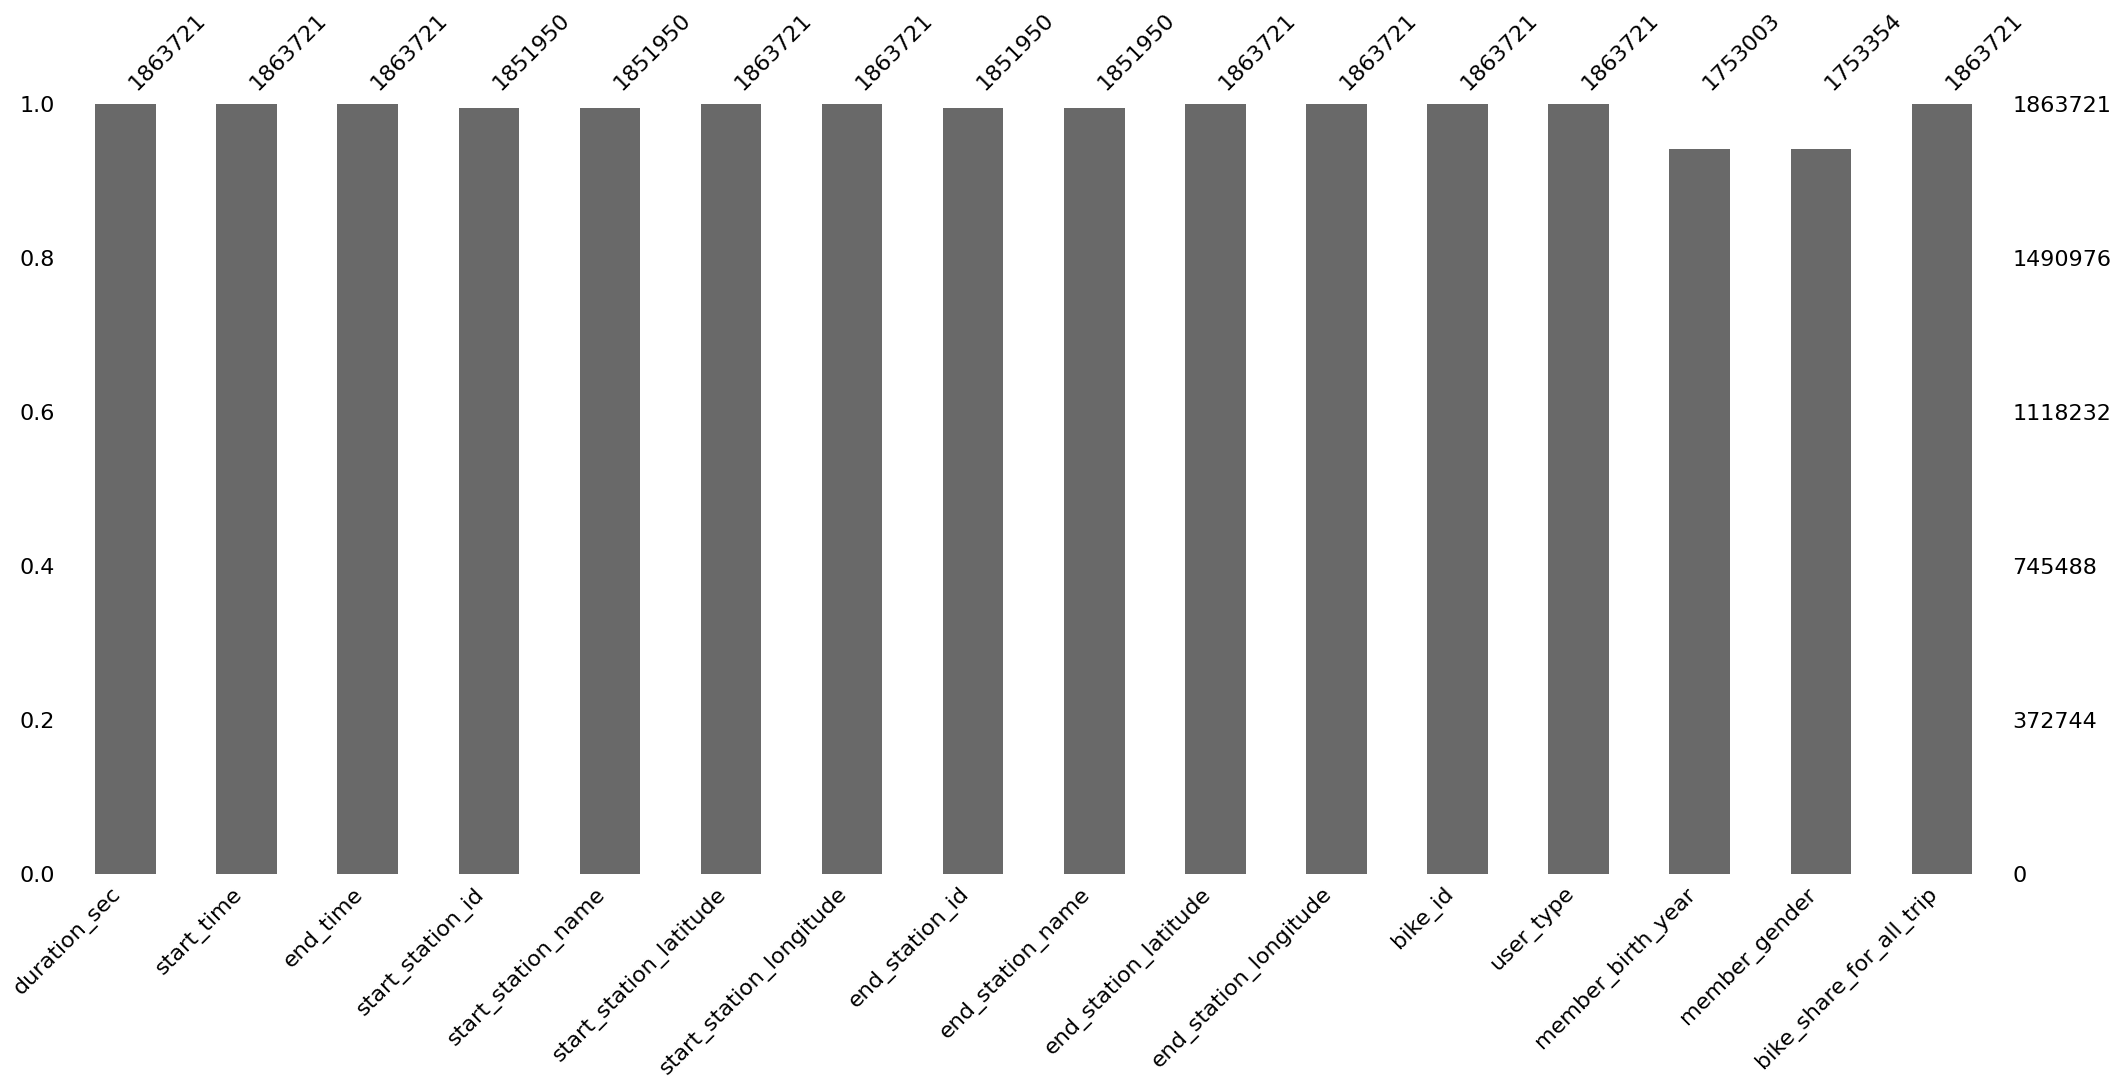

In [10]:
# Visualizing the missing values
import missingno as msno
plt.figure(figsize=(8,5))
msno.bar(merged_df)

### What did you know about your dataset?

The datasets explains that a Ford company rental their bike to their customer for their independent ride and charged them for their trip.
Two types of customers are their:
- **Subscribers**
- **Casual customers**.

We need to identify the factors affecting the:
- Trip duration to be shorter resulting in less revenue.
- How to focus on customer retention ratio.
- Whether the trip affected by seasons/weather.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
merged_df.columns

# 16 columns in the dataset

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='object')

In [12]:
# Dataset Describe
# merged_df[["duration_sec","start_station_latitude","start_station_longitude"]].describe()
merged_df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,1.863721e+06,1.851950e+06,1.863721e+06,1.863721e+06,1.851950e+06,1.863721e+06,1.863721e+06,1.863721e+06,1.753003e+06
mean,8.573026e+02,1.196744e+02,3.776678e+01,-1.223492e+02,1.181730e+02,3.776690e+01,-1.223487e+02,2.296851e+03,1.983088e+03
std,2.370379e+03,1.003976e+02,1.057689e-01,1.654634e-01,1.004403e+02,1.056483e-01,1.650597e-01,1.287733e+03,1.044289e+01
min,6.100000e+01,3.000000e+00,3.726331e+01,-1.224737e+02,3.000000e+00,3.726331e+01,-1.224737e+02,1.100000e+01,1.881000e+03
25%,3.500000e+02,3.300000e+01,3.777106e+01,-1.224114e+02,3.000000e+01,3.777106e+01,-1.224094e+02,1.225000e+03,1.978000e+03
50%,5.560000e+02,8.900000e+01,3.778107e+01,-1.223974e+02,8.800000e+01,3.778127e+01,-1.223971e+02,2.338000e+03,1.985000e+03
75%,8.720000e+02,1.860000e+02,3.779625e+01,-1.222865e+02,1.830000e+02,3.779728e+01,-1.222894e+02,3.333000e+03,1.991000e+03
max,8.636600e+04,3.810000e+02,4.551000e+01,-7.357000e+01,3.810000e+02,4.551000e+01,-7.357000e+01,6.234000e+03,2.000000e+03


### Variables Description

- duration_sec - Trip Duration in seconds
- start_time - Trip start time date and time
- end_time - Trip end time date and time
- start_station_id - Station id in Float
- start_station_name	- Name in string
- start_station_latitude - float
- start_station_longitude	- float
- end_station_id - float
- end_station_name - Name in string
- end_station_latitude - float
- end_station_longitude - float
- bike_id	- Int
- user_type	- Object
- member_birth_year	- int
- member_gender	- Object
- bike_share_for_all_trip - yes/No

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
merged_df.nunique()

,0
duration_sec,16709
start_time,372064
end_time,371553
start_station_id,331
start_station_name,348
start_station_latitude,369
start_station_longitude,369
end_station_id,331
end_station_name,348
end_station_latitude,370


In [14]:
merged_df["member_gender"].unique()

array(['Male', nan, 'Female', 'Other'], dtype=object)

## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# Write your code to make your dataset analysis ready.

In [16]:
merged_df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,31-01-2018 22:52,01-02-2018 19:47,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,31-01-2018 16:13,01-02-2018 15:57,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,31-01-2018 14:23,01-02-2018 10:16,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,31-01-2018 14:53,01-02-2018 07:51,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,31-01-2018 19:52,01-02-2018 06:58,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No


In [17]:
merged_df['start_time'] = pd.to_datetime(merged_df['start_time'],format='%d-%m-%Y %H:%M')
merged_df['end_time'] = pd.to_datetime(merged_df['end_time'],format='%d-%m-%Y %H:%M')

In [18]:
merged_df['start_station_id'] = merged_df['start_station_id'].astype(str)
merged_df['end_station_id'] = merged_df['end_station_id'].astype(str)
merged_df['bike_id'] = merged_df['bike_id'].astype(str)

#### ***Memory Usage of three categorical datatype(User_type,Member_gender, bike_share_for_all_trip before converting categorical data from Object to Category dtype***

In [19]:
merged_df.memory_usage(deep=True)

,0
Index,132
duration_sec,14909768
start_time,14909768
end_time,14909768
start_station_id,99475337
start_station_name,140877307
start_station_latitude,14909768
start_station_longitude,14909768
end_station_id,99455919
end_station_name,141813093


In [20]:
merged_df['user_type'] = merged_df['user_type'].astype('category')
# merged_df['member_gender'] = merged_df['member_gender'].astype('category')
merged_df['bike_share_for_all_trip'] = merged_df['bike_share_for_all_trip'].astype('category')

#why we have typecasting these category columns - because the datatype object is literally storing data for every single row.
# So python provide us to typecast the category columns to category- Memory efficient, speed output, clearer plotting
# Object dtypes takes high memory.

Dropping those rows where the start_station_id, end_station_id,start_station_name, end_station_name are null because it can affect our relevant insights.

In [21]:
merged_df.dropna(subset=['start_station_id','end_station_id','start_station_name','end_station_name'],inplace=True)

Gender with NULL values filled with **Unknown**

In [22]:
merged_df['member_gender'] = merged_df['member_gender'].fillna('Unknown')

In [23]:
# GLOBAL MEDIAN
merged_df['member_birth_year'].median()

1985.0

In [24]:
merged_df.isnull().sum()

,0
duration_sec,0
start_time,0
end_time,0
start_station_id,0
start_station_name,0
start_station_latitude,0
start_station_longitude,0
end_station_id,0
end_station_name,0
end_station_latitude,0


Checking the **Median value** in both category(**Subscriber and Casual**) first instead of directly filling the Null values with **Global Median**.

In [25]:
merged_df.groupby('user_type',observed=True)['member_birth_year'].agg(['count', 'median', lambda x: x.isnull().sum()])

# observed=True , It actually shows the existing categories and not those which have count=0

,count,median,<lambda_0>
user_type,,,
Customer,199189,1987.0,77770
Subscriber,1542367,1985.0,32624


The category show the casual customer is having more null values in year columns, it means casual customer are not filling their birth year which correlate with other things like(trip purpose, Duration patterns etc.)

#### Filling up **null_values** with median in member_birth_year for each user_type category wise.

In [26]:
merged_df.groupby('user_type',observed=True)['member_birth_year'].transform(lambda x: x.fillna(x.median()))

,member_birth_year
0,1986.0
1,1987.0
2,1996.0
3,1987.0
4,1991.0
...,...
1863716,1982.0
1863717,1999.0
1863718,1991.0
1863719,1963.0


Minimum Birth Year is 1881, it means the member in 2018 is 137 years old which is hypothetical about a rider. It shows that casaul riders enter a random birth year instead of real.

Decided to drop it.

In [27]:
merged_df['member_birth_year'].min()

1881.0

In [28]:
merged_df['member_birth_year'].sort_values().head(20)


,member_birth_year
883138,1881.0
882515,1881.0
882646,1881.0
882987,1881.0
880583,1881.0
1578650,1888.0
1085201,1888.0
1529361,1888.0
1108698,1888.0
1567432,1888.0


#### Low outliers (< 1930, ~137+ years old) → 1,413 rows, decided to drop.

In [29]:
merged_df[merged_df['member_birth_year'] < 1930].shape[0]

1413

Since the count of members whose birth year <1930 is less so it's better to drop these rows.

In [30]:
merged_df = merged_df[merged_df['member_birth_year']>1930]

In [31]:
merged_df['member_birth_year'].max()


2000.0

Max year 2000 shows there are. It means the typical minimum age requirement is 18.

#### ***Memory Usage drops after converting categorical data from Object to Category dtype***

In [32]:
merged_df['member_gender'] = merged_df['member_gender'].astype('category')


In [33]:
merged_df.memory_usage(deep=True)

,0
Index,13921136
duration_sec,13921136
start_time,13921136
end_time,13921136
start_station_id,92907909
start_station_name,131863647
start_station_latitude,13921136
start_station_longitude,13921136
end_station_id,92891286
end_station_name,132778771


### What all manipulations have you done and insights you found?

Typecasting:
1. **Start_time** - from object to standard date_time format
2. **End_time** - from object to standard date_time format
3. **Start_station_id**, **end_station_id**, **bike_id** - from float and int to str to not get plotted in graphs as numerical columns.
4. **member_gender**, **User_type** and **bike_ride_for_all_trips** - from object to categorical data type to make it memory efficient, easy to plot with recommended color, speed output.
5. **member_birth_year** imputed with the median value for each user_type category(Subscriber and Customer). This approach was choosen because customer has higher rate of missing birth year data(28%) compare to Subscribers(0.08%).
6. Those **1413** rows were dropped from the dataset because it shows the users(before 1930) with age exceeding 88 in 2018 most likely data entry errors or placeholder values.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### **1. UNIVARIATE ANALYSIS**

#### 1.1 - How Long does the average trip take?

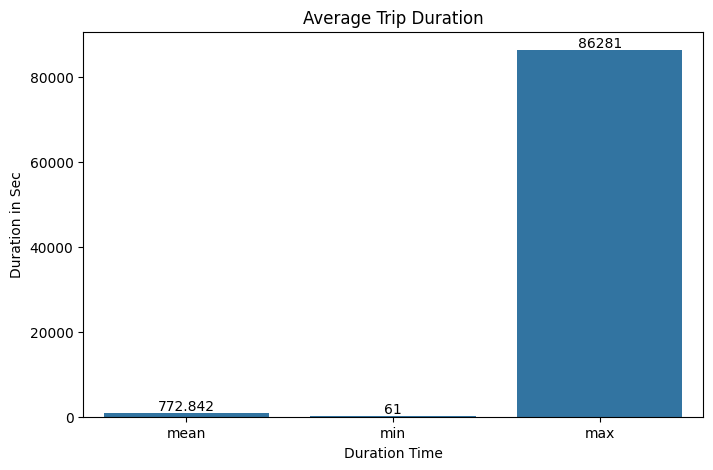

In [34]:
# Chart - 1 visualization code
merged_df.head()
avg_trip = merged_df['duration_sec'].agg(['mean','min','max'])
plt.figure(figsize=(8,5))
avg_trip_plot = sns.barplot(x=avg_trip.index,y=avg_trip.values)
plt.title('Average Trip Duration')
plt.xlabel('Duration Time')
plt.ylabel('Duration in Sec')
for i in avg_trip_plot.containers:
  avg_trip_plot.bar_label(i)
plt.show()


##### **1. Why did you pick the specific chart?**

---



I have picked Bar chart from seaborn lib to show the Average_trip along with minimum and maximum trip duration in seconds.
It shows 773 seconds is average trip duration which is very shorter than the maximum trip duration.

##### **2. What is/are the insight(s) found from the chart?**

Average trip duration is 772 seconds(12.9 minutes) while the maximum trip duration dramatically higher indicating the presence of extreme outliers

##### **3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.**

Yes. The average trip duration help us to keep more bikes availability for trip and also to emphasis on converting casual customers to Subscribers

#### **1.2 Is the trip duration affected by weather/seasons?**

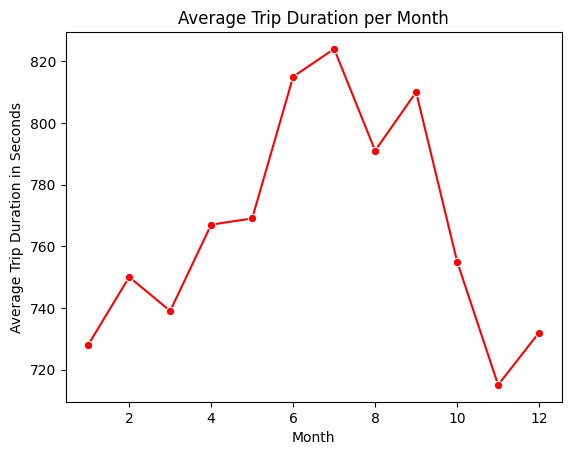

In [35]:
# Chart - 2 visualization code
merged_df.head()
merged_df['month'] = merged_df['start_time'].dt.month
monthly_avg_tripduration = round(merged_df.groupby('month')['duration_sec'].mean()).reset_index().rename(columns={'duration_sec':'Avg_duration_in_sec'})

sns.lineplot(data=monthly_avg_tripduration,x='month',y='Avg_duration_in_sec',color='Red',marker='o')
plt.title('Average Trip Duration per Month')
plt.xlabel('Month')
plt.ylabel('Average Trip Duration in Seconds')
plt.show()

- **Why this chart:** A line chart was chosen because month is a continuous/sequential variable (Jan→Dec), and a line plot is well-suited to showing how average trip duration trends and fluctuates across the year.
- **Insights:** Average trip duration peaks in July at 824 seconds, higher than other months, suggesting a seasonal pattern where trips are longer during summer.
- **Business impact:** Knowing that trip duration peaks in summer helps the company anticipate higher bike utilization per trip during these months — useful for planning bike availability, maintenance scheduling, and potentially introducing seasonal pricing or promotions to capture increased leisure ridership in summer.
- **Negative growth risk:** If duration is shorter in colder months (e.g., winter), this may indicate reduced leisure ridership or riders avoiding longer trips in poor weather — a seasonal dip in usage that could translate to lower revenue during those months if the business model depends on trip volume or duration-based pricing.

**1.3 Daily Trip Duration**

In [36]:
merged_df['day'] = merged_df['start_time'].dt.day
daily_avg_tripduration = round(merged_df.groupby('day')['duration_sec'].mean()).reset_index().rename(columns={'duration_sec':'Avg_duration_in_sec'})
daily_avg_tripduration

,day,Avg_duration_in_sec
0,1,793.0
1,2,784.0
2,3,832.0
3,4,781.0
4,5,744.0
5,6,760.0
6,7,786.0
7,8,781.0
8,9,754.0
9,10,768.0


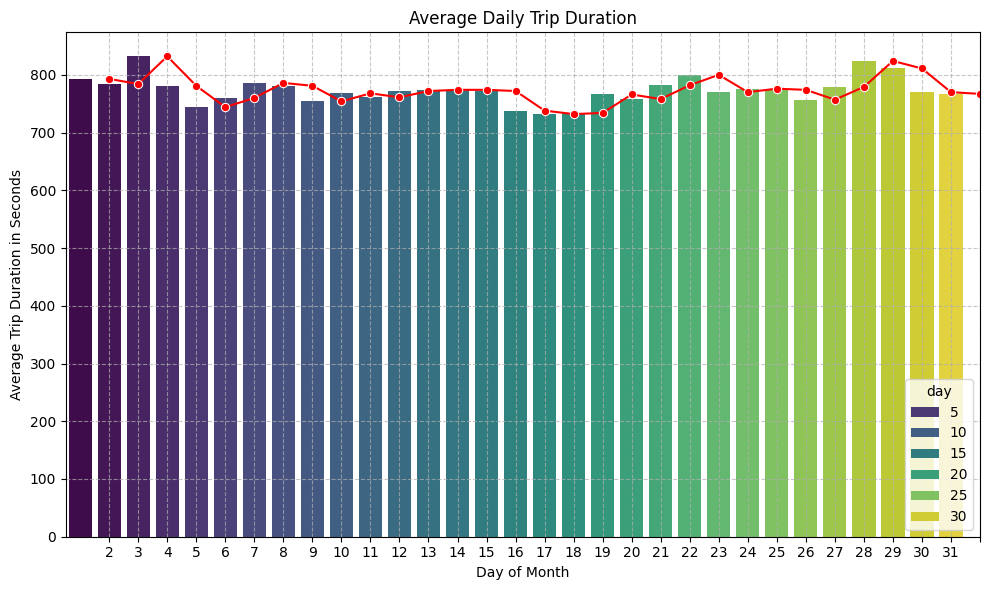

In [37]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=daily_avg_tripduration, x='day', y='Avg_duration_in_sec', color='Red', marker='o')
sns.barplot(data=daily_avg_tripduration, x='day', y='Avg_duration_in_sec', hue='day',palette='viridis')
plt.title('Average Daily Trip Duration')
plt.xlabel('Day of Month')
plt.ylabel('Average Trip Duration in Seconds')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, 32)) # Ensure all days are shown
plt.tight_layout()
plt.show()

- **Why this chart:** A line chart is suitable for displaying trends over a continuous numerical variable like 'day'. It effectively shows the fluctuation of average trip duration across the days of the month, making it easy to spot peaks and troughs.
- **Insights:** The line chart reveals how the average trip duration varies day-by-day. There isn't a strong, consistent upward or downward trend across the month, but it highlights specific days with higher or lower average durations, such as day 3 (832 sec) and day 28 (824 sec) having some of the highest average durations.
- **Business impact:** Understanding daily fluctuations can help in resource allocation, such as ensuring more bikes are available on days with historically longer trip durations. It can also inform marketing strategies for specific days with lower usage.
- **Negative growth risk:** Days with significantly shorter average trip durations might indicate lower engagement or specific factors that discourage longer rides on those days, potentially leading to reduced revenue if pricing is duration-dependent.

**1.4 Trip Duration Distrubution**

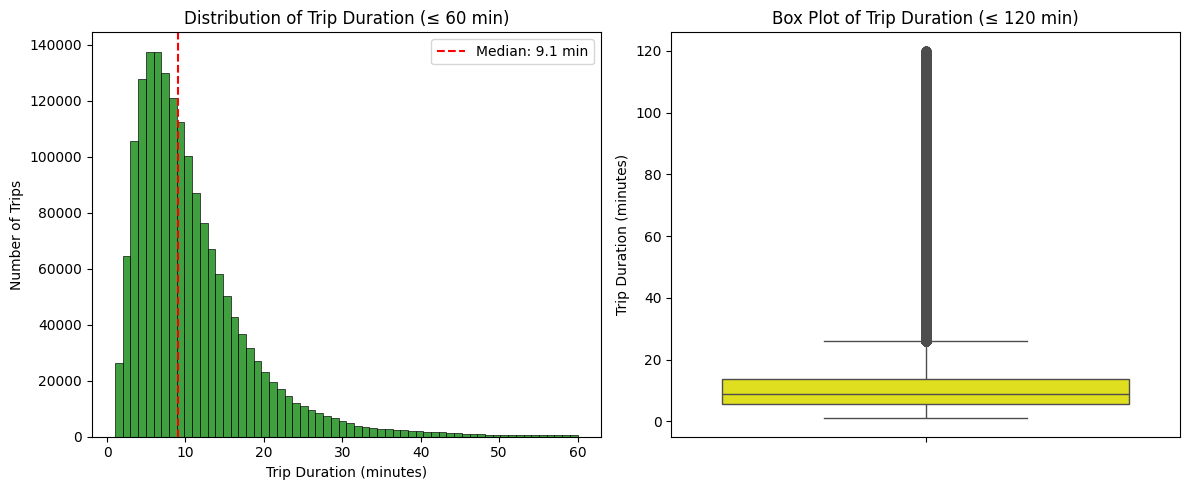

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
merged_df['duration_min'] = merged_df['duration_sec']/60
merged_df_duration = merged_df['duration_min'].median()

# Left: Histogram capped at 60 min
sns.histplot(merged_df[merged_df['duration_min'] <= 60]['duration_min'], bins=60, ax=axes[0],color='green')
axes[0].axvline(merged_df_duration, color='red', linestyle='--', label=f'Median: {merged_df_duration:.1f} min')
axes[0].set_title('Distribution of Trip Duration (≤ 60 min)')
axes[0].set_xlabel('Trip Duration (minutes)')
axes[0].set_ylabel('Number of Trips')
axes[0].legend()

# Right: Boxplot capped at 120 min
sns.boxplot(y=merged_df[merged_df['duration_min'] <= 120]['duration_min'], ax=axes[1],color='yellow')
axes[1].set_title('Box Plot of Trip Duration (≤ 120 min)')
axes[1].set_ylabel('Trip Duration (minutes)')

plt.tight_layout()
plt.show()

**1.5 User Type Distribution**

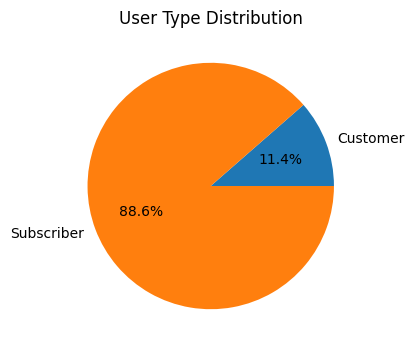

In [39]:
user_type_count = merged_df.groupby('user_type',observed=False)['bike_id'].count().reset_index().rename(columns={'bike_id':'user_count'})
user_type_count['user_percentage'] = round(user_type_count['user_count']*100/user_type_count['user_count'].sum(),2)
plt.figure(figsize=(4,4))
plt.pie(user_type_count['user_count'], labels=user_type_count['user_type'], autopct='%1.1f%%')
plt.title('User Type Distribution')
plt.show()

**Why this chart:** Pie chart suits `user_type` since it has only two categories, making proportions easy to compare visually.

**Insight:** Subscribers make up 88.6% of trips, Customers make up 11.4% — the platform is dominated by recurring users.

**Business impact:**
- Positive: High Subscriber share means stable, predictable recurring usage.
- Negative: Small Customer base limits the pipeline for converting new riders into Subscribers, which could slow long-term growth.

**1.6 Gender Distribution**

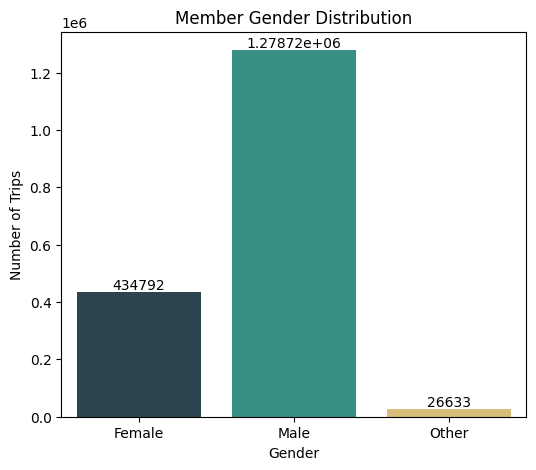

In [40]:
plt.figure(figsize=(6,5))
gender_wise_count = merged_df.groupby('member_gender',observed=False)['bike_id'].count().reset_index().rename(columns={'bike_id':'count'})
colors = ['#264653', '#2A9D8F', '#E9C46A']
gender_plot = sns.barplot(data=gender_wise_count, x='member_gender', y=gender_wise_count['count'],hue='member_gender',palette=colors)
plt.title('Member Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Trips')
for i in gender_plot.containers:
  gender_plot.bar_label(i)
plt.show()

**Why this chart:** Barplot suits `member_gender` since it's categorical — bar heights make it easy to compare counts across groups.

**Insight:** Male riders make up the largest share of trips, followed by Female, with Other/Unknown a small minority.

**Business impact:**
- Positive: Clear majority segment (Male) can be a reliable target for core marketing.
- Negative: Underrepresentation of Female and Other riders suggests missed growth opportunity — targeted campaigns could expand this segment.

**1.7 Age Distribution**

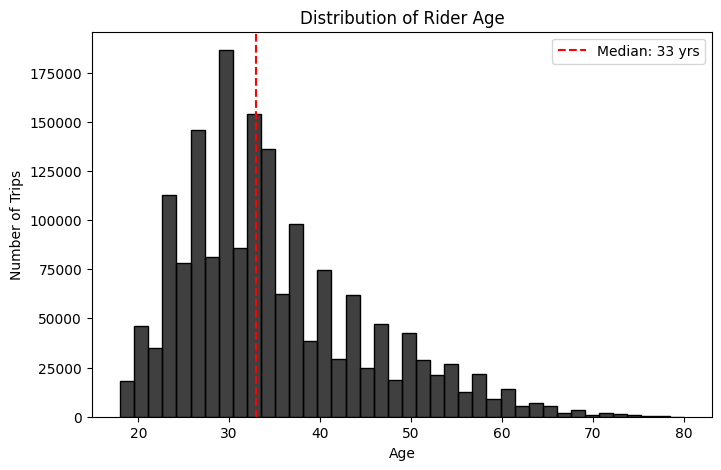

In [41]:
merged_df['age'] = 2018 - merged_df['member_birth_year']
plt.figure(figsize=(8,5))
sns.histplot(merged_df[merged_df['age'] <= 80]['age'], bins=40,color='black')
plt.axvline(merged_df['age'].median(), color='red', linestyle='--', label=f"Median: {merged_df['age'].median():.0f} yrs")
plt.title('Distribution of Rider Age')
plt.xlabel('Age')
plt.ylabel('Number of Trips')
plt.legend()
plt.show()

**Why this chart:** Histogram suits `age` since it's continuous — shows the full shape of the distribution, not just one summary number.

**Insight:** Rider age is concentrated around 30-35 years, with a median of 33 years, and tapers off at older ages.

**Business impact:**
- Positive: Concentrated age range enables focused marketing and product design for that demographic.
- Negative: Low representation of older/younger riders signals an underserved segment — expanding accessibility or messaging could grow the user base.

**1.8 Bike Share for All Program**

In [42]:
merged_df.isna().sum()

,0
duration_sec,0
start_time,0
end_time,0
start_station_id,0
start_station_name,0
start_station_latitude,0
start_station_longitude,0
end_station_id,0
end_station_name,0
end_station_latitude,0


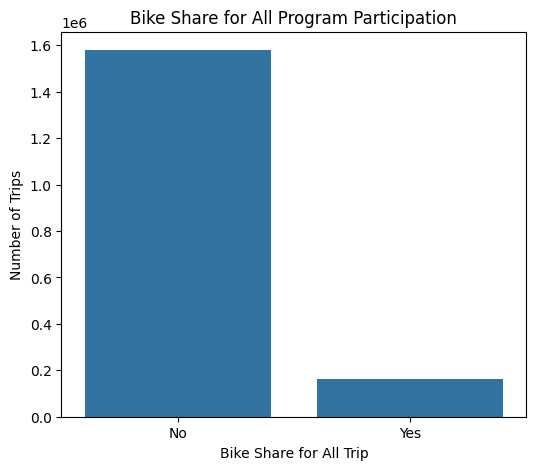

In [43]:
plt.figure(figsize=(6,5))
sns.countplot(data=merged_df, x='bike_share_for_all_trip')
plt.title('Bike Share for All Program Participation')
plt.xlabel('Bike Share for All Trip')
plt.ylabel('Number of Trips')
plt.show()

**Why this chart:** Countplot suits `bike_share_for_all_trip` since it's a binary Yes/No category — easy to compare participation counts.

**Insight:** The large majority of trips are not part of the Bike Share for All program, with only a small share of trips coming from enrolled riders.

**Business impact:**
- Positive: Low current enrollment means significant room to grow this program, which likely serves lower-income riders and supports equity/accessibility goals.
- Negative: Low awareness or adoption could mean the program isn't reaching its intended audience — worth investigating outreach effectiveness.

### **2. BIVARIATE ANALYSIS**

**2.1 Trip Duration by User Type**

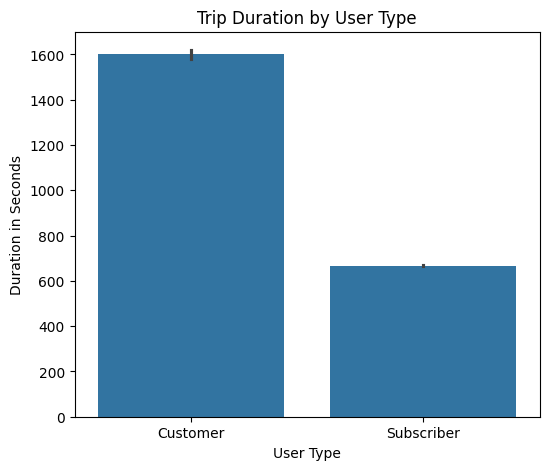

In [44]:
plt.figure(figsize=(6,5))
sns.barplot(data=merged_df, x='user_type', y='duration_sec')
plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Duration in Seconds')
plt.show()

**Why this chart:** Barplot compares average duration across the two `user_type` categories.

**Insight:** Customers have a higher average trip duration than Subscribers, suggesting Subscribers use bikes for quick commutes while Customers ride more for leisure.

**Business impact:**
- Positive: Confirms different usage motivations, useful for tailored pricing.
- Negative: Longer Customer trips may tie up bikes longer, reducing availability for other riders.

**2.2 Hourly Pattern by User Type**

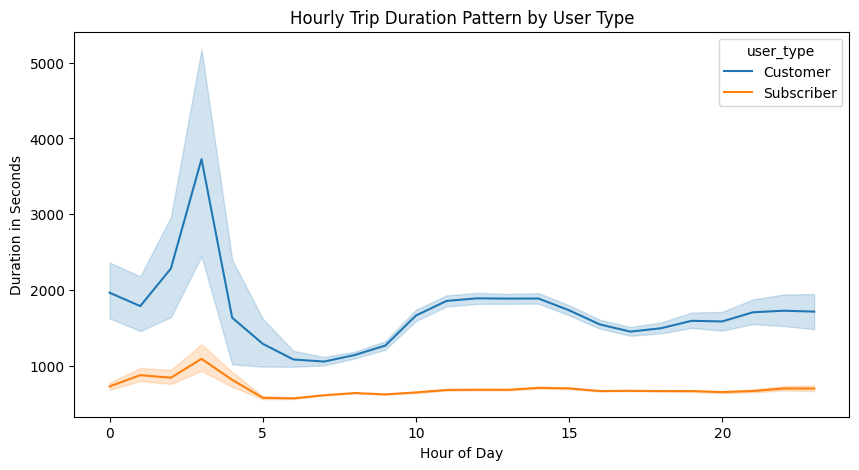

In [45]:
merged_df['hour'] = merged_df['start_time'].dt.hour

plt.figure(figsize=(10,5))
sns.lineplot(data=merged_df, x='hour', y='duration_sec', hue='user_type')
plt.title('Hourly Trip Duration Pattern by User Type')
plt.xlabel('Hour of Day')
plt.ylabel('Duration in Seconds')
plt.show()

**Why this chart:** Line chart shows trend across hours, split by user type using hue.

**Insight:** Subscribers show short, steady durations across all hours, while Customers show longer and more variable durations, especially outside commute hours.

**Business impact:**
- Positive: Confirms Subscribers follow predictable commute patterns, useful for fleet planning.
- Negative: Inconsistent Customer usage outside peak hours suggests low weekday engagement from casual riders.

**2.3 Trip Duration by Day of Week**

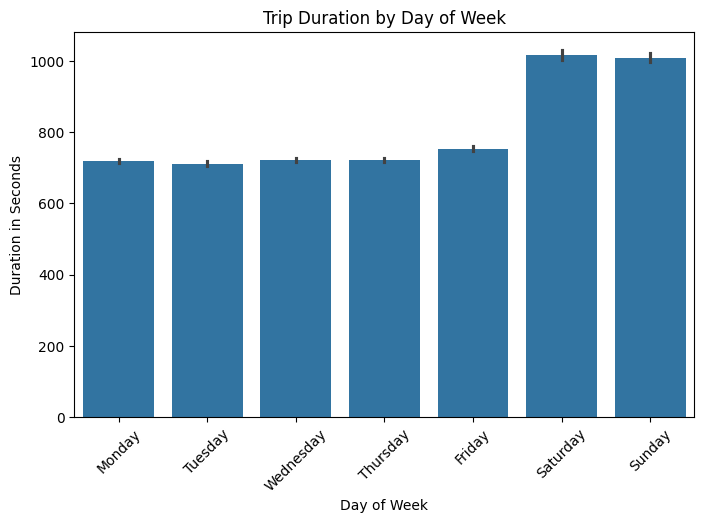

In [46]:
merged_df['day_of_week'] = merged_df['start_time'].dt.day_name()

plt.figure(figsize=(8,5))
sns.barplot(data=merged_df, x='day_of_week', y='duration_sec', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Trip Duration by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Duration in Seconds')
plt.xticks(rotation=45)
plt.show()

**Why this chart:** Barplot compares average duration across each day of the week.

**Insight:** Trip duration is higher on weekends (Saturday, Sunday) compared to weekdays, suggesting more leisure riding on weekends.

**Business impact:**
- Positive: Supports weekend promotions targeting leisure riders.
- Negative: Shorter weekday durations reflect utility-only usage, meaning limited upsell opportunity during the work week.

**2.4 Trips by Gender & User Type**

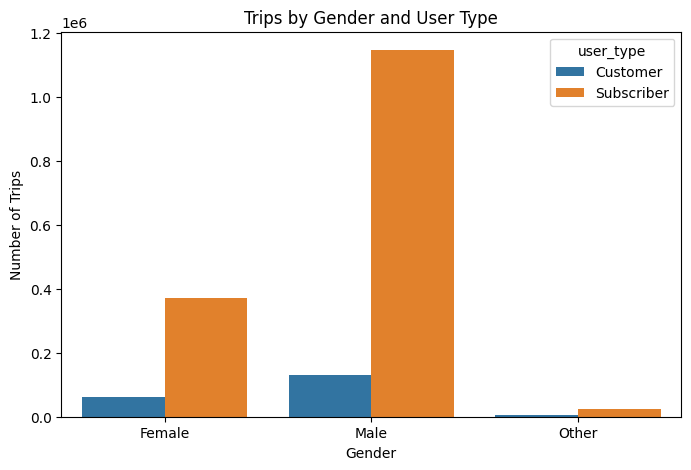

In [47]:
plt.figure(figsize=(8,5))
sns.countplot(data=merged_df, x='member_gender', hue='user_type')
plt.title('Trips by Gender and User Type')
plt.xlabel('Gender')
plt.ylabel('Number of Trips')
plt.show()

**Why this chart:** Countplot with hue compares trip counts across gender, split further by user type.

**Insight:** Male riders have the highest trip counts in both Subscriber and Customer groups, with Subscribers outnumbering Customers across all gender categories.

**Business impact:**
- Positive: Male Subscribers form the core, most reliable user base.
- Negative: Low counts among Female and Other riders across both user types suggest an underserved segment worth targeting.

**2.5 Age Distribution by User Type**

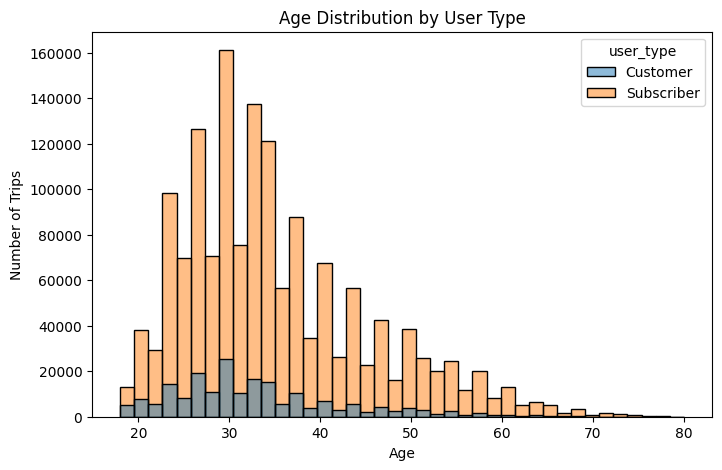

In [48]:
merged_df['age'] = 2018 - merged_df['member_birth_year']

plt.figure(figsize=(8,5))
sns.histplot(data=merged_df[merged_df['age']<=80], x='age', hue='user_type', bins=40)
plt.title('Age Distribution by User Type')
plt.xlabel('Age')
plt.ylabel('Number of Trips')
plt.show()

**Why this chart:** Histogram with hue compares age distribution shape between the two user types.

**Insight:** Subscribers are concentrated in a narrower, younger age range, while Customers show a wider age spread including older riders.

**Business impact:**
- Positive: Core Subscriber age group can be targeted directly for retention campaigns.
- Negative: Wider Customer age spread makes it harder to design one-size-fits-all conversion campaigns.

**2.6 Trip Duration by Gender**

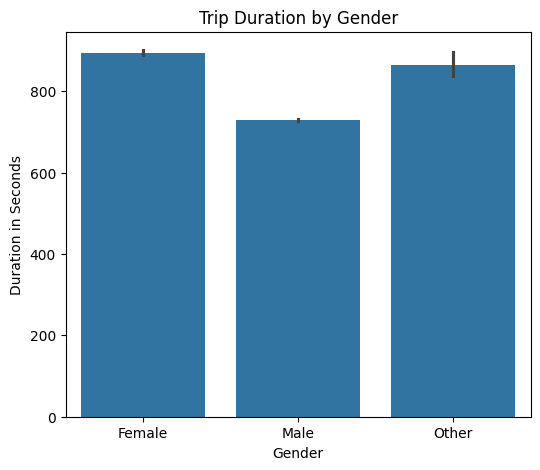

In [49]:
plt.figure(figsize=(6,5))
sns.barplot(data=merged_df, x='member_gender', y='duration_sec')
plt.title('Trip Duration by Gender')
plt.xlabel('Gender')
plt.ylabel('Duration in Seconds')
plt.show()

**Why this chart:** Barplot compares average duration across gender categories.

**Insight:** Average trip duration is broadly similar across genders, with only minor differences.

**Business impact:**
- Positive: Trip length isn't a differentiating factor by gender, so pricing/marketing don't need gender-specific duration adjustments.
- Negative: No strong risk signal from this chart alone.

**2.7 Monthly Trend by User Type**

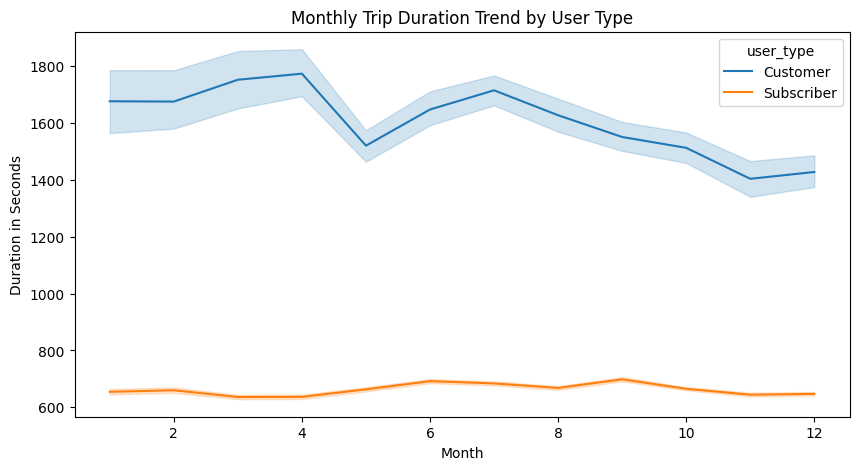

In [50]:
merged_df['month'] = merged_df['start_time'].dt.month

plt.figure(figsize=(10,5))
sns.lineplot(data=merged_df, x='month', y='duration_sec', hue='user_type')
plt.title('Monthly Trip Duration Trend by User Type')
plt.xlabel('Month')
plt.ylabel('Duration in Seconds')
plt.show()

**Why this chart:** Line chart tracks duration trend across months, split by user type.

**Insight:** Customer duration rises more noticeably in summer months, while Subscriber duration stays relatively flat year-round.

**Business impact:**
- Positive: Supports seasonal marketing pushes for Customers during summer.
- Negative: Customer engagement dropping in colder months suggests seasonal revenue volatility from that segment.

### **3. MULTIVARIATE ANALYSIS**

**3.1 Heatmap: Hour × Day of Week**

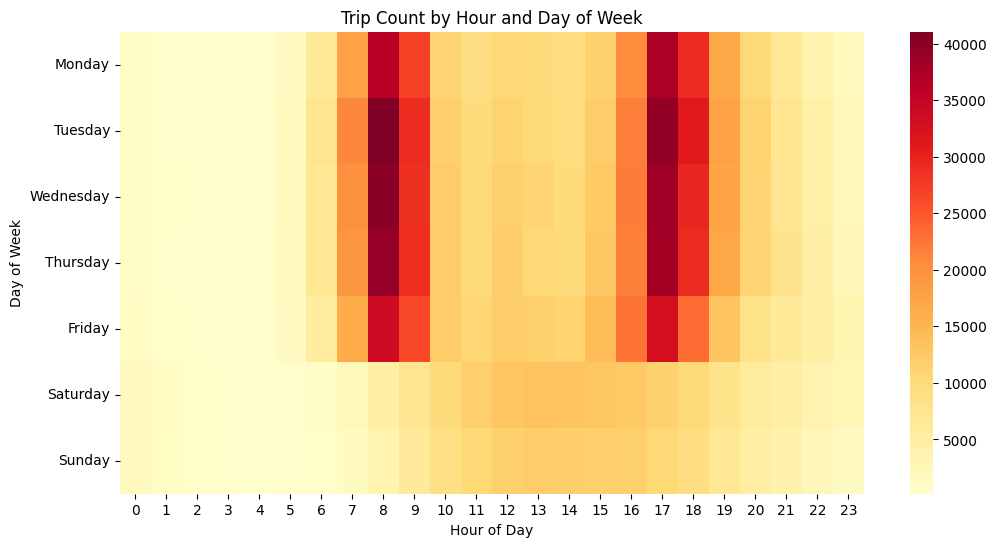

In [51]:
merged_df['hour'] = merged_df['start_time'].dt.hour
merged_df['day_of_week'] = merged_df['start_time'].dt.day_name()

pivot_table = merged_df.pivot_table(index='day_of_week', columns='hour', values='bike_id', aggfunc='count')
pivot_table = pivot_table.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap='YlOrRd')
plt.title('Trip Count by Hour and Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

**Why this chart:** Heatmap shows trip counts across two categories at once (hour and day), with color intensity making peak times easy to spot.

**Insight:** Trip counts are highest on weekday mornings and evenings (around 8 AM and 5 PM), while weekends show a more spread-out, lower-intensity pattern.

**Business impact:**
- Positive: Confirms exact peak windows, useful for precise bike rebalancing before rush hours.
- Negative: Low weekend activity across all hours suggests underused fleet capacity on weekends.

**3.2 Correlation Heatmap**

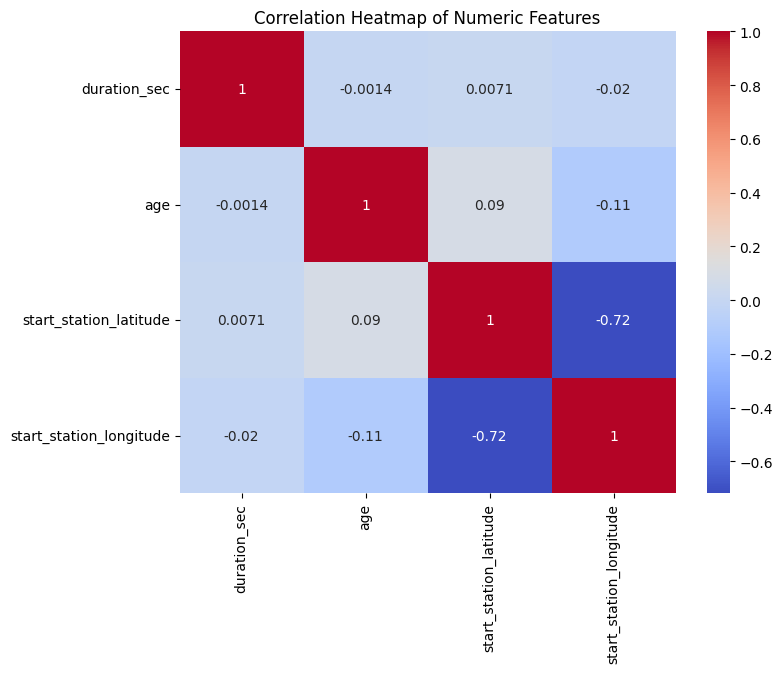

In [52]:
numeric_cols = merged_df[['duration_sec', 'age', 'start_station_latitude', 'start_station_longitude']]

plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

**Why this chart:** Heatmap with annotations shows correlation strength between all numeric variables at once, in one view.

**Insight:** Most numeric variables show weak correlation with each other, with duration and age showing little to no strong relationship.

**Business impact:**
- Positive: Confirms trip duration isn't strongly driven by rider age, meaning duration patterns are more behavior-based than demographic-based.
- Negative: Weak correlations mean no single numeric factor strongly predicts trip duration, so pricing/planning may need to rely on categorical patterns (day, hour, user type) instead.

**3.3 Pair Plot Analysis**

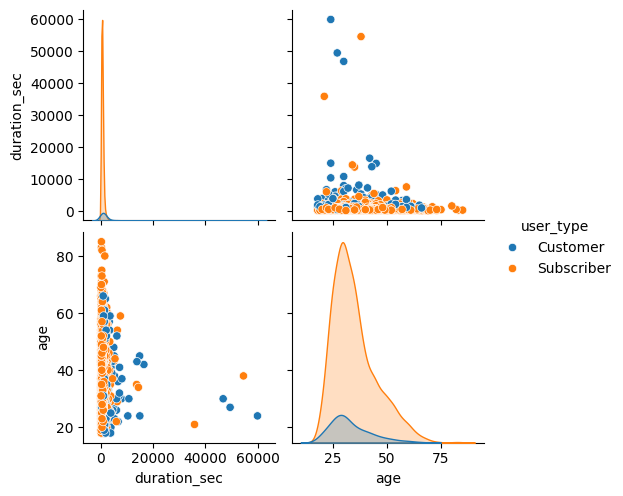

In [53]:
pairplot_df = merged_df[['duration_sec', 'age', 'user_type']].sample(5000)

sns.pairplot(pairplot_df, hue='user_type')
plt.show()

**Why this chart:** Pair plot shows relationships between multiple numeric variables at once, split by user type, useful for spotting patterns across combinations.

**Insight:** Duration and age don't show a clear linear relationship, but Subscribers and Customers form somewhat separate clusters, especially in duration.

**Business impact:**
- Positive: Distinct clustering by user type confirms these two segments behave differently, supporting separate strategies for each.
- Negative: No strong insight suggesting decline — mainly confirms existing segmentation patterns.

**4.1 Top 10 Start Stations**

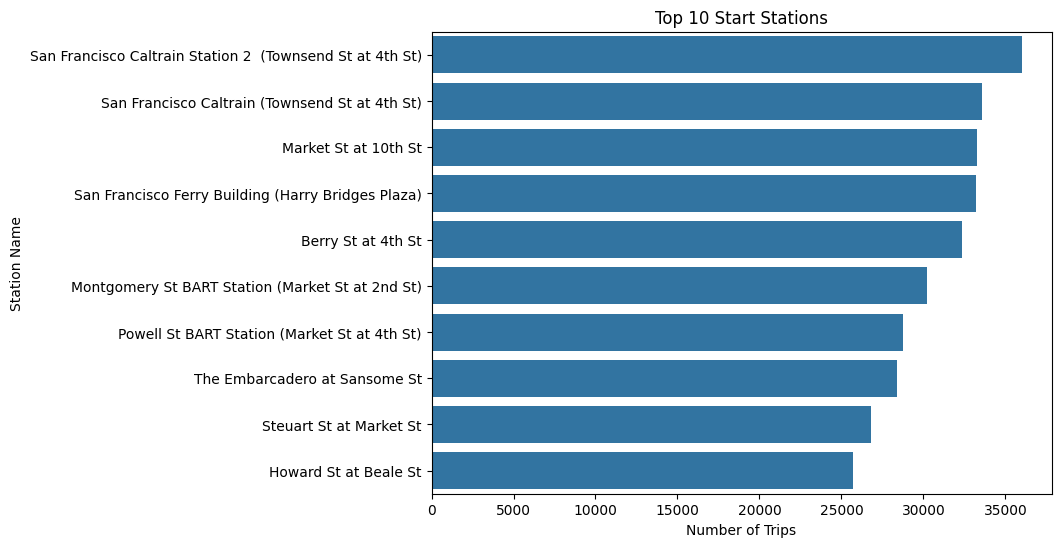

In [54]:
top_start = merged_df['start_station_name'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_start.values, y=top_start.index)
plt.title('Top 10 Start Stations')
plt.xlabel('Number of Trips')
plt.ylabel('Station Name')
plt.show()

**Why this chart:** Horizontal barplot ranks the top 10 start stations by trip count, easy to read station names alongside their values.

**Insight:** A small number of stations account for a disproportionately high share of trip starts, likely located in high-traffic business or transit areas.

**Business impact:**
- Positive: High-traffic stations can be prioritized for bike availability and maintenance.
- Negative: Heavy reliance on a few stations means any disruption there (maintenance, docking issues) significantly impacts overall ridership.

**4.2 Top 10 End Stations**

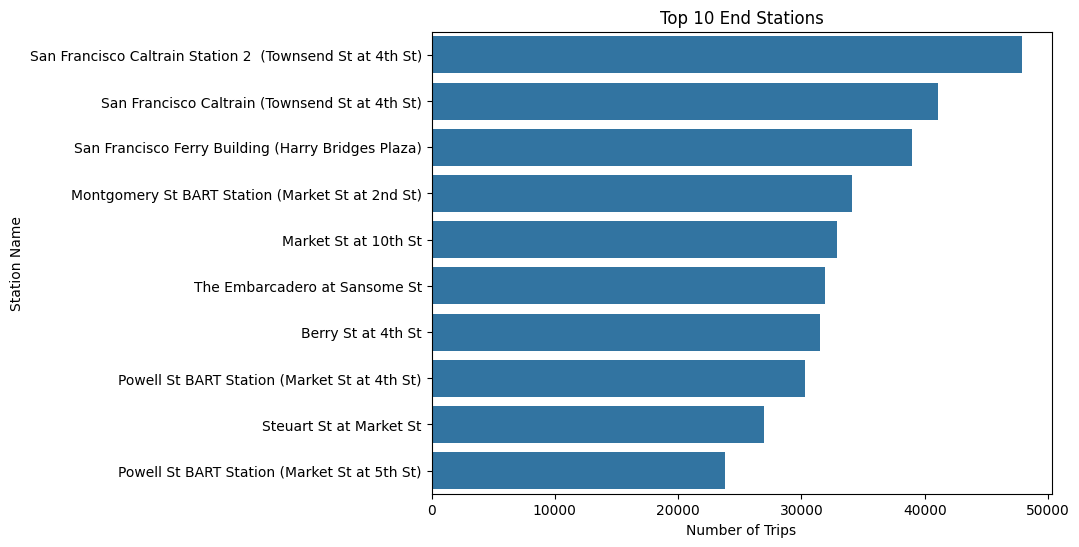

In [55]:
top_end = merged_df['end_station_name'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_end.values, y=top_end.index)
plt.title('Top 10 End Stations')
plt.xlabel('Number of Trips')
plt.ylabel('Station Name')
plt.show()

**Why this chart:** Horizontal barplot ranks the top 10 end stations by trip count, matching the format used for start stations for easy comparison.

**Insight:** The top end stations largely overlap with the top start stations, suggesting these are central hubs where trips both begin and conclude.

**Business impact:**
- Positive: Overlapping start/end hubs simplify rebalancing logistics — bikes naturally cycle back through these key locations.
- Negative: If end-station demand consistently exceeds start-station supply at certain hubs, it could cause bike shortages there during peak hours.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

## Recommendations to Achieve the Business Objective

**1. Rebalance bikes around peak demand windows**
Since trip activity spikes sharply on weekday mornings (8 AM) and evenings (5 PM) and concentrates at a small number of top stations, the client should prioritize redistributing bikes to these stations just before peak hours to avoid shortages.

**2. Target Customers with Subscriber conversion campaigns**
Customers show longer, more leisure-oriented trips and less complete profile data compared to Subscribers. Offering trial Subscriptions, discounts, or weekend-to-weekday incentives could help convert repeat Customers into recurring Subscribers, improving predictable revenue.

**3. Introduce seasonal and weekend promotions**
Customer usage rises in summer months and on weekends, suggesting a leisure-driven pattern. Seasonal passes or weekend bundle pricing could better capture this demand rather than treating all riders under one flat pricing model.

**4. Monitor and flag long-duration trips**
Trips far beyond typical duration likely represent lost, stolen, or undocked bikes rather than genuine rides. Setting an automated duration threshold for flagging and following up on these trips can reduce fleet losses and operational costs.

**5. Expand outreach to underrepresented demographics**
Male riders and a mid-age adult bracket currently dominate ridership. Marketing campaigns aimed at underrepresented genders and age groups could broaden the user base and unlock additional growth.

**6. Strengthen high-traffic station infrastructure**
Since a small number of stations handle a disproportionate share of trips, the client should prioritize maintenance, docking capacity, and reliability at these hub stations, since disruptions there would have outsized impact on overall service.

Together, these steps use the patterns found in the data — timing, user segments, demographics, and station demand — to directly support the business objective of operational efficiency, revenue growth, and improved rider retention.

# **Conclusion**

## Conclusion

- Cleaned and merged twelve months of raw Ford GoBike data into a single, analysis-ready dataset through careful wrangling — fixing data types, handling missing values via group-wise imputation, and removing implausible outliers.

- Found that **Subscribers** ride frequently for short, consistent durations during weekday commute hours, while **Customers** ride less often but for longer, leisure-style trips, especially on weekends and in summer.

- Identified demographic concentration in a core adult age group and among male riders, highlighting clear segments for targeted growth campaigns.

- Found trip activity concentrated at a small number of high-traffic stations, emphasizing their operational importance.

- Flagged risk areas: extreme-duration trips (likely lost/undocked bikes), heavy reliance on a few stations, and strong dependence on weekday commuting.

- These insights directly support the business objective — guiding fleet rebalancing, Subscriber conversion campaigns, seasonal marketing, loss reduction, and outreach to underrepresented rider segments.

- Overall, the project shows how structured data wrangling and EDA can turn raw operational data into practical, actionable business insight.

## ***Hurrah! You have successfully completed your EDA Capstone Project !!!***